# AI-Driven Intrusion Detection System — Pipeline v7
**Uses separate train.csv and test.csv files.**
**v6 upgrade: full 15-class multiclass classification (no binary simplification, no scope filter).**

| Label | Attack Type |
|-------|-------------|
| 0  | BENIGN |
| 1  | PortScan |
| 2  | Infiltration |
| 3  | Web Attack – Brute Force |
| 4  | Web Attack – XSS |
| 5  | Web Attack – SQL Injection |
| 6  | DDoS |
| 7  | DoS Hulk |
| 8  | DoS GoldenEye |
| 9  | DoS Slowloris |
| 10 | DoS Slowhttptest |
| 11 | FTP-Patator |
| 12 | SSH-Patator |
| 13 | Bot |
| 14 | Heartbleed |

**v6 changes:** Logistic Regression switched to `saga` solver with `n_jobs=-1` for significantly faster training and lower RAM usage on large datasets. Removed deprecated `use_label_encoder` from XGBoost. Removed redundant `f1_score` import in Step 13.

**v7 changes:** SMOTE capped at 10,000 samples per minority class (prevents dataset explosion). Random Forest reduced to 50 estimators. Logistic Regression `tol=1e-3` for faster convergence.


## STEP 1 — Install Libraries (run once only)

In [2]:
# Remove the # below, run once, then add the # back
#!pip install pandas numpy scikit-learn matplotlib seaborn xgboost joblib imbalanced-learn

## STEP 2 — Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score,
    precision_score, recall_score, f1_score
)

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print('✅ SMOTE available')
except ImportError:
    SMOTE_AVAILABLE = False
    print('⚠️  SMOTE not available — pip install imbalanced-learn')

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print('✅ XGBoost available')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('⚠️  XGBoost not available — pip install xgboost')

print('\nAll libraries imported!')


✅ SMOTE available
✅ XGBoost available

All libraries imported!


## STEP 3 — Load train.csv and test.csv

In [4]:
# Load training data
df_train = pd.read_csv('train.csv', encoding='utf-8', low_memory=False)
df_train.columns = df_train.columns.str.strip()
print(f'Train loaded: {df_train.shape[0]:,} rows, {df_train.shape[1]} columns')

# Load test data
df_test = pd.read_csv('test.csv', encoding='utf-8', low_memory=False)
df_test.columns = df_test.columns.str.strip()
print(f'Test  loaded: {df_test.shape[0]:,} rows, {df_test.shape[1]} columns')


Train loaded: 2,059,411 rows, 80 columns
Test  loaded: 514,853 rows, 80 columns


## STEP 4 — Label Mapping (15-Class)
Map the numeric `Label` column to human-readable attack type names.
All 15 categories are kept — no binary simplification.

Train label distribution:
AttackType
BENIGN                        1718709
DoS Hulk                       138279
DDoS                           102413
PortScan                        72655
DoS GoldenEye                    8229
FTP-Patator                      4746
DoS Slowloris                    4308
DoS Slowhttptest                 4182
SSH-Patator                      2575
Bot                              1562
Web Attack - Brute Force         1176
Web Attack - XSS                  522
Infiltration                       29
Web Attack - SQL Injection         17
Heartbleed                          9
Name: count, dtype: int64

Test label distribution:
AttackType
BENIGN                        429677
DoS Hulk                       34570
DDoS                           25603
PortScan                       18164
DoS GoldenEye                   2057
FTP-Patator                     1187
DoS Slowloris                   1077
DoS Slowhttptest                1046
SSH-Patator                      6

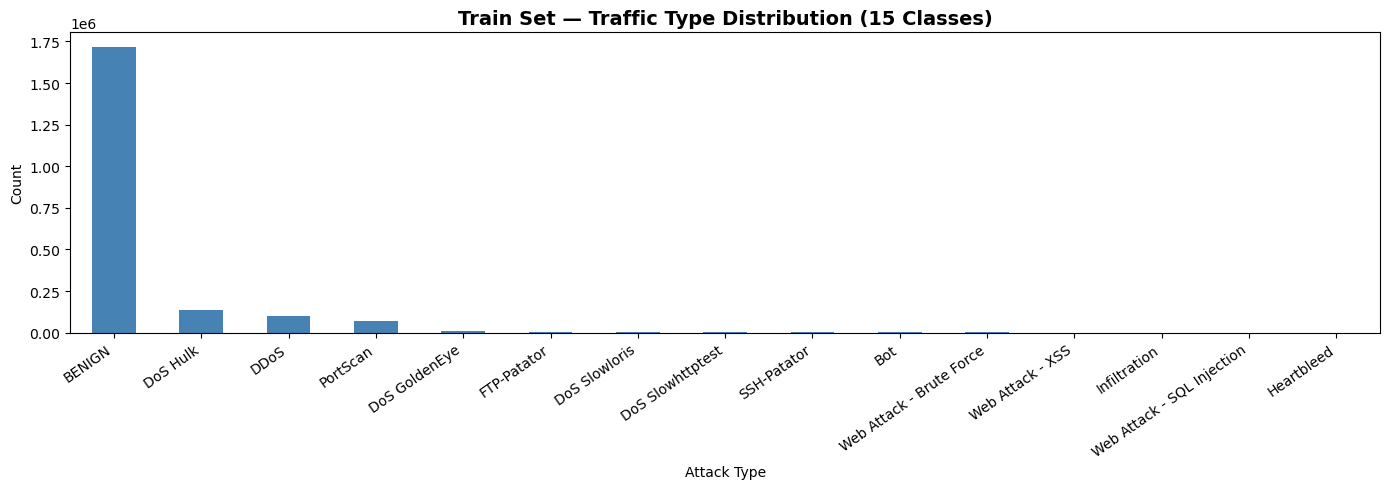

In [5]:
LABEL_MAP = {
    0:  'BENIGN',
    1:  'PortScan',
    2:  'Infiltration',
    3:  'Web Attack - Brute Force',
    4:  'Web Attack - XSS',
    5:  'Web Attack - SQL Injection',
    6:  'DDoS',
    7:  'DoS Hulk',
    8:  'DoS GoldenEye',
    9:  'DoS Slowloris',
    10: 'DoS Slowhttptest',
    11: 'FTP-Patator',
    12: 'SSH-Patator',
    13: 'Bot',
    14: 'Heartbleed',
}

CLASS_NAMES = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]

# Apply to train and test — use the numeric Label directly as the target
df_train['AttackType'] = df_train['Label'].map(LABEL_MAP)
df_test['AttackType']  = df_test['Label'].map(LABEL_MAP)

print('Train label distribution:')
print(df_train['AttackType'].value_counts())
print('\nTest label distribution:')
print(df_test['AttackType'].value_counts())

# Plot train distribution
df_train['AttackType'].value_counts().plot(kind='bar', figsize=(14, 5), color='steelblue')
plt.title('Train Set — Traffic Type Distribution (15 Classes)', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()


## STEP 5 — Clean Both Datasets
Remove unnecessary columns, drop infinities, NaNs, and duplicates.
In v5 all 15 classes are retained — no label filtering.

In [6]:
def clean_df(df, name):
    print(f'{name} before cleaning: {df.shape}')
    df.drop(columns=['source', 'AttackType'], inplace=True, errors='ignore')
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    df.drop_duplicates(inplace=True)
    print(f'{name} after  cleaning: {df.shape}')
    return df

df_train = clean_df(df_train, 'Train')
df_test  = clean_df(df_test,  'Test')


Train before cleaning: (2059411, 81)
Train after  cleaning: (2023662, 79)
Test before cleaning: (514853, 81)
Test after  cleaning: (511898, 79)


## STEP 6 — Feature Selection

In [7]:
SELECTED_FEATURES = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Flow IAT Mean',
    'Flow IAT Std',
    'Fwd IAT Mean',
    'Bwd IAT Mean',
    'Packet Length Mean',
    'Packet Length Std',
    'Destination Port',
    'Average Packet Size',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'Fwd Packets/s',
    'Bwd Packets/s',
    'SYN Flag Count',
    'ACK Flag Count',
    'PSH Flag Count',
    'Init_Win_bytes_forward',
    'Init_Win_bytes_backward',
]

available = [f for f in SELECTED_FEATURES if f in df_train.columns]
missing   = [f for f in SELECTED_FEATURES if f not in df_train.columns]

if missing:
    print(f'Skipped (not in CSV): {missing}')
print(f'Using {len(available)} features.')
print(available)


Using 24 features.
['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Fwd IAT Mean', 'Bwd IAT Mean', 'Packet Length Mean', 'Packet Length Std', 'Destination Port', 'Average Packet Size', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Fwd Packets/s', 'Bwd Packets/s', 'SYN Flag Count', 'ACK Flag Count', 'PSH Flag Count', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward']


## STEP 7 — Prepare X and y, Scale (No Data Leakage)
Target `y` is the multiclass numeric `Label` (0–14).
The scaler is fit on training data only to prevent data leakage.

In [8]:
# Separate features and multiclass labels
X_train_raw = df_train[available].values
y_train     = df_train['Label'].values      # 0–14 multiclass

X_test_raw  = df_test[available].values
y_test      = df_test['Label'].values       # 0–14 multiclass

# Fit scaler on TRAIN only, transform both — no data leakage
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Train : {X_train.shape[0]:,} samples, {X_train.shape[1]} features')
print(f'Test  : {X_test.shape[0]:,} samples, {X_test.shape[1]} features')
print(f'Classes in train: {sorted(np.unique(y_train))}')
print(f'Classes in test : {sorted(np.unique(y_test))}')

joblib.dump(scaler,    'scaler.pkl')
joblib.dump(available, 'feature_columns.pkl')
joblib.dump(LABEL_MAP, 'label_map.pkl')
print('\nscaler.pkl saved')
print('feature_columns.pkl saved')
print('label_map.pkl saved')


Train : 2,023,662 samples, 24 features
Test  : 511,898 samples, 24 features
Classes in train: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
Classes in test : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]

scaler.pkl saved
feature_columns.pkl saved
label_map.pkl saved


## STEP 8 — Apply SMOTE to Training Set Only
SMOTE oversamples minority classes so all 15 categories are better represented.
Applied to the multiclass `y_train`; test set is never touched.

In [9]:
if SMOTE_AVAILABLE:
    print('Applying SMOTE to training set (multiclass)...')
    # v6: cap each minority class at 10,000 samples instead of matching the
    # majority class. Without this, SMOTE can inflate the training set 10-15x
    # (e.g. if BENIGN has 500k rows, every class gets upsampled to 500k),
    # making all subsequent model training extremely slow.
    majority_count = int(np.bincount(y_train).max())
    smote_cap      = min(majority_count, 10_000)
    sampling_strat = {
        cls: max(count, smote_cap)
        for cls, count in zip(*np.unique(y_train, return_counts=True))
        if count < smote_cap
    }
    smote = SMOTE(sampling_strategy=sampling_strat, random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
    print(f'Before SMOTE — class counts: {dict(zip(*np.unique(y_train, return_counts=True)))}')
    print(f'After  SMOTE — class counts: {dict(zip(*np.unique(y_train_bal, return_counts=True)))}')
else:
    X_train_bal, y_train_bal = X_train, y_train
    print('SMOTE skipped — using original training data')
    print('Class counts:', dict(zip(*np.unique(y_train, return_counts=True))))


Applying SMOTE to training set (multiclass)...
Before SMOTE — class counts: {np.int64(0): np.int64(1682960), np.int64(1): np.int64(72655), np.int64(2): np.int64(29), np.int64(3): np.int64(1176), np.int64(4): np.int64(522), np.int64(5): np.int64(17), np.int64(6): np.int64(102413), np.int64(7): np.int64(138279), np.int64(8): np.int64(8229), np.int64(9): np.int64(4308), np.int64(10): np.int64(4182), np.int64(11): np.int64(4746), np.int64(12): np.int64(2575), np.int64(13): np.int64(1562), np.int64(14): np.int64(9)}
After  SMOTE — class counts: {np.int64(0): np.int64(1682960), np.int64(1): np.int64(72655), np.int64(2): np.int64(10000), np.int64(3): np.int64(10000), np.int64(4): np.int64(10000), np.int64(5): np.int64(10000), np.int64(6): np.int64(102413), np.int64(7): np.int64(138279), np.int64(8): np.int64(10000), np.int64(9): np.int64(10000), np.int64(10): np.int64(10000), np.int64(11): np.int64(10000), np.int64(12): np.int64(10000), np.int64(13): np.int64(10000), np.int64(14): np.int64(10

## STEP 9 — Train Supervised Models (Multiclass)
All three supervised models are configured for 15-class classification.
- **Logistic Regression** — baseline, `multi_class='multinomial'`
- **Random Forest** — main classifier, handles multiclass natively
- **XGBoost** — advanced classifier with `objective='multi:softprob'`

In [10]:
NUM_CLASSES = len(LABEL_MAP)  # 15

# ── Logistic Regression (Baseline) ───────────────────────────────────────
# v6: switched to saga solver — much faster & lower RAM on large datasets.
# saga handles multiclass natively (multinomial by default), supports n_jobs,
# and converges reliably with far fewer iterations than lbfgs.
print('Training Logistic Regression (multiclass)...')
lr = LogisticRegression(max_iter=500, solver='saga', tol=1e-3,
                        n_jobs=-1, random_state=42)
lr.fit(X_train_bal, y_train_bal)
lr_pred  = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)      # shape (n_samples, 15)
print(f'  Accuracy: {accuracy_score(y_test, lr_pred):.4f}')

# ── Random Forest (Main Classifier) ──────────────────────────────────────
print('\nTraining Random Forest (multiclass)...')
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)      # shape (n_samples, 15)
print(f'  Accuracy: {accuracy_score(y_test, rf_pred):.4f}')

# ── XGBoost (Advanced) ───────────────────────────────────────────────────
if XGBOOST_AVAILABLE:
    print('\nTraining XGBoost (multiclass)...')
    xgb = XGBClassifier(
        objective='multi:softprob',
        num_class=NUM_CLASSES,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(X_train_bal, y_train_bal)
    xgb_pred  = xgb.predict(X_test)
    xgb_proba = xgb.predict_proba(X_test)   # shape (n_samples, 15)
    print(f'  Accuracy: {accuracy_score(y_test, xgb_pred):.4f}')

print('\n✅ Supervised models trained!')


Training Logistic Regression (multiclass)...
  Accuracy: 0.9436

Training Random Forest (multiclass)...
  Accuracy: 0.9981

Training XGBoost (multiclass)...
  Accuracy: 0.8731

✅ Supervised models trained!


## STEP 10 — Train Isolation Forest (Anomaly Detector)
Isolation Forest is trained on BENIGN-only traffic and flags anomalies.
In multiclass context it acts as a binary anomaly signal alongside the 15-class classifiers.

In [11]:
# Train on BENIGN rows from training set only
X_train_benign = X_train[y_train == 0]
print(f'Training Isolation Forest on {X_train_benign.shape[0]:,} BENIGN samples...')

iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
iso.fit(X_train_benign)

iso_raw  = iso.predict(X_test)
iso_pred = np.where(iso_raw == -1, 1, 0)   # -1=anomaly→1, 1=normal→0
iso_score = -iso.score_samples(X_test)      # higher = more anomalous

# For Isolation Forest, map binary predictions to class 0 (BENIGN) or -1 (unknown attack)
# Report accuracy against a binary view (0=benign, 1=any attack)
y_test_binary = (y_test != 0).astype(int)
print(f'Anomaly detection accuracy (binary): {accuracy_score(y_test_binary, iso_pred):.4f}')
print('Note: Isolation Forest outputs binary (BENIGN/anomaly), not 15 classes.')


Training Isolation Forest on 1,682,960 BENIGN samples...
Anomaly detection accuracy (binary): 0.8869
Note: Isolation Forest outputs binary (BENIGN/anomaly), not 15 classes.


## STEP 11 — Full Evaluation Reports (15-Class)
Per-class precision, recall, and F1-score for all 15 traffic categories.

In [12]:
def evaluate(name, y_true, y_pred, target_names=None):
    print(f'\n{"="*65}')
    print(f'  {name}')
    print(f'{"="*65}')
    print(classification_report(y_true, y_pred, target_names=target_names,
                                 zero_division=0))

evaluate('Logistic Regression (Baseline)', y_test, lr_pred,  CLASS_NAMES)
evaluate('Random Forest (Main)',           y_test, rf_pred,  CLASS_NAMES)
if XGBOOST_AVAILABLE:
    evaluate('XGBoost (Advanced)',         y_test, xgb_pred, CLASS_NAMES)



  Logistic Regression (Baseline)
                            precision    recall  f1-score   support

                    BENIGN       0.96      0.98      0.97    426722
                  PortScan       0.66      0.98      0.79     18164
              Infiltration       0.04      0.71      0.08         7
  Web Attack - Brute Force       0.00      0.00      0.00       294
          Web Attack - XSS       0.00      0.00      0.00       130
Web Attack - SQL Injection       0.00      0.00      0.00         4
                      DDoS       0.96      0.67      0.79     25603
                  DoS Hulk       0.93      0.88      0.90     34570
             DoS GoldenEye       0.81      0.49      0.61      2057
             DoS Slowloris       0.85      0.20      0.32      1077
          DoS Slowhttptest       0.39      0.19      0.25      1046
               FTP-Patator       0.00      0.00      0.00      1187
               SSH-Patator       0.00      0.00      0.00       644
             

## STEP 12 — Model Comparison Table
Macro-averaged precision, recall, and F1-score across all 15 classes.
ROC-AUC is computed using the one-vs-rest (OvR) strategy.

In [ ]:
def get_metrics(y_true, y_pred, y_proba=None):
    row = {
        'Accuracy (%)':  round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision (%)': round(precision_score(y_true, y_pred, average='macro', zero_division=0) * 100, 2),
        'Recall (%)':    round(recall_score(y_true, y_pred, average='macro', zero_division=0) * 100, 2),
        'F1-Score (%)':  round(f1_score(y_true, y_pred, average='macro', zero_division=0) * 100, 2),
    }
    if y_proba is not None:
        # OvR ROC-AUC for multiclass
        try:
            row['ROC-AUC (OvR)'] = round(
                roc_auc_score(y_true, y_proba, multi_class='ovr',
                              average='macro', labels=list(range(15))), 4
            )
        except Exception as e:
            row['ROC-AUC (OvR)'] = float('nan')
            print(f'  ROC-AUC skipped: {e}')
    return row

results = {
    'Logistic Regression': get_metrics(y_test, lr_pred, lr_proba),
    'Random Forest':       get_metrics(y_test, rf_pred, rf_proba),
}
if XGBOOST_AVAILABLE:
    results['XGBoost'] = get_metrics(y_test, xgb_pred, xgb_proba)

results_df = pd.DataFrame(results).T
print('\n📊 Model Comparison Table (macro-averaged over 15 classes)')
print(results_df.to_string())

results_df.to_csv('model_comparison.csv')
print('\nSaved: model_comparison.csv')


## STEP 13 — Visualisations

In [ ]:
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# ── Accuracy Bar Chart ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
results_df['Accuracy (%)'].plot(kind='bar', ax=ax,
                                 color=COLORS[:len(results_df)])
ax.set_title('Model Accuracy Comparison (15-Class)', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
ax.set_xticklabels(results_df.index, rotation=20, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150)
plt.show()


In [ ]:
# ── All Metrics Grouped Bar ───────────────────────────────────────────────
plot_cols = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
results_df[plot_cols].plot(kind='bar', figsize=(11, 6), colormap='tab10')
plt.title('Model Performance Metrics (Macro-Averaged, 15 Classes)',
          fontsize=14, fontweight='bold')
plt.ylabel('%')
plt.ylim(0, 115)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150)
plt.show()


In [ ]:
# ── Confusion Matrix — Random Forest (15×15) ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
cm = confusion_matrix(y_test, rf_pred, labels=list(range(15)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.3)
ax.set_title('Random Forest — Confusion Matrix (15 Classes)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confusion Matrix — Logistic Regression ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
cm_lr = confusion_matrix(y_test, lr_pred, labels=list(range(15)))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.3)
ax.set_title('Logistic Regression — Confusion Matrix (15 Classes)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

if XGBOOST_AVAILABLE:
    fig, ax = plt.subplots(figsize=(14, 12))
    cm_xgb = confusion_matrix(y_test, xgb_pred, labels=list(range(15)))
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.3)
    ax.set_title('XGBoost — Confusion Matrix (15 Classes)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.xticks(rotation=35, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig('confusion_matrix_xgb.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
# ── Per-Class F1-Score Bar Chart (Random Forest) ─────────────────────────
rf_f1_per_class = f1_score(y_test, rf_pred, average=None,
                            labels=list(range(15)), zero_division=0)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(CLASS_NAMES, rf_f1_per_class * 100, color='steelblue')
ax.set_title('Random Forest — Per-Class F1-Score (15 Classes)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score (%)')
ax.set_ylim(0, 115)
plt.xticks(rotation=35, ha='right', fontsize=9)
for bar, val in zip(bars, rf_f1_per_class):
    ax.annotate(f'{val*100:.1f}',
                (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('f1_per_class_rf.png', dpi=150)
plt.show()


In [ ]:
# ── Feature Importance (Random Forest) ───────────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=available).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(12, 5), color='steelblue')
plt.title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print('Top 5 most important features:')
print(feat_imp.head())


## STEP 14 — Save All Models

In [ ]:
joblib.dump(lr,         'logistic_regression_model.pkl')
joblib.dump(rf,         'random_forest_model.pkl')
joblib.dump(iso,        'isolation_forest_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(available,  'feature_columns.pkl')
joblib.dump(LABEL_MAP,  'label_map.pkl')
joblib.dump(CLASS_NAMES,'class_names.pkl')

if XGBOOST_AVAILABLE:
    joblib.dump(xgb, 'xgboost_model.pkl')

print('✅ All models saved:')
print('   logistic_regression_model.pkl')
print('   random_forest_model.pkl')
print('   isolation_forest_model.pkl')
print('   scaler.pkl')
print('   feature_columns.pkl')
print('   label_map.pkl')
print('   class_names.pkl')
if XGBOOST_AVAILABLE:
    print('   xgboost_model.pkl')


## STEP 15 — Live Prediction Test (Flask dry-run)
Simulates how Flask will load the saved model, scale a raw input, and return
the predicted **attack category** (one of 15 classes) plus confidence score.

In [ ]:
# Simulate what Flask will do: load saved model, scale input, predict
loaded_rf        = joblib.load('random_forest_model.pkl')
loaded_scaler    = joblib.load('scaler.pkl')
loaded_features  = joblib.load('feature_columns.pkl')
loaded_label_map = joblib.load('label_map.pkl')

# Take 10 raw (unscaled) samples from test set
sample_raw = X_test_raw[:10]
sample_y   = y_test[:10]

# Scale using saved scaler
sample_scaled = loaded_scaler.transform(sample_raw)
preds  = loaded_rf.predict(sample_scaled)
probas = loaded_rf.predict_proba(sample_scaled)   # shape (10, 15)

print('Live Prediction Test — Random Forest (15-Class)')
print('-' * 65)
for i, (actual, pred, proba_row) in enumerate(zip(sample_y, preds, probas)):
    actual_name = loaded_label_map[actual]
    pred_name   = loaded_label_map[pred]
    confidence  = proba_row[pred] * 100
    status = '✓' if actual == pred else '✗'
    print(f'  [{status}] Row {i+1:2d}: Actual={actual_name:30s}  '
          f'Predicted={pred_name:30s}  Confidence={confidence:.1f}%')


---
## ✅ Output Files
| File | Purpose |
|------|---------|
| `random_forest_model.pkl` | Main 15-class classifier → Flask |
| `isolation_forest_model.pkl` | Anomaly detector → Flask |
| `logistic_regression_model.pkl` | Baseline comparison |
| `xgboost_model.pkl` | Advanced comparison |
| `scaler.pkl` | Fit on train only — no leakage |
| `feature_columns.pkl` | Feature order for Flask |
| `label_map.pkl` | Label number → name for Flask |
| `class_names.pkl` | Ordered list of 15 class names |
| `model_comparison.csv` | Paste into report |
| `accuracy_comparison.png` | Model accuracy chart |
| `metrics_comparison.png` | All macro-averaged metrics chart |
| `confusion_matrix_rf.png` | Random Forest 15×15 confusion matrix |
| `confusion_matrix_lr.png` | Logistic Regression 15×15 confusion matrix |
| `confusion_matrix_xgb.png` | XGBoost 15×15 confusion matrix |
| `f1_per_class_rf.png` | Per-class F1 bar chart (RF) |
| `feature_importance.png` | RF feature importance |
| `label_distribution.png` | Dataset distribution |
